# 11 — The Lurcher

Allomantic iron: the Ironpull, the Steelpush's mirror (`sim/ironpull.py`).
Same force pair, same falloff, opposite sign — barely thirty lines. The
interesting physics is the part that *isn't* mirrored, predicted before
implementation:

**A push's downward component presses loose metal into the ground and
manufactures grip (notebook 09's 59° lesson). A pull's component lifts the
metal and destroys grip. So no pull on loose metal should ever anchor — at
any angle.** If that emerges, it explains why canon rates Lurchers below
Coinshots: a Coinshot mints anchors from pocket change; a Lurcher can only
move himself against the bones of the world.

Known gap, stated: the engine has no body-body collision and no hands. A
pulled coin passes through the Lurcher (we measure when it *reaches* him),
and a grapple held too long sails through the beam (experiments release on
approach, which is also what canon Lurchers do, or they eat the lamppost).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Steelpush, Ironpull

## Experiment A — the asymmetry, head to head

Notebook 09's angle sweep, run both ways: at each angle, how long does the
coin stay anchored under a 2000 N push versus a 2000 N pull? The push curve
should show the 59° cliff (and the hold-until-your-arc-betrays-you decay
above it). The pull curve should be flat zero — every pulled coin comes
free immediately, because pulling *un-grips* it.

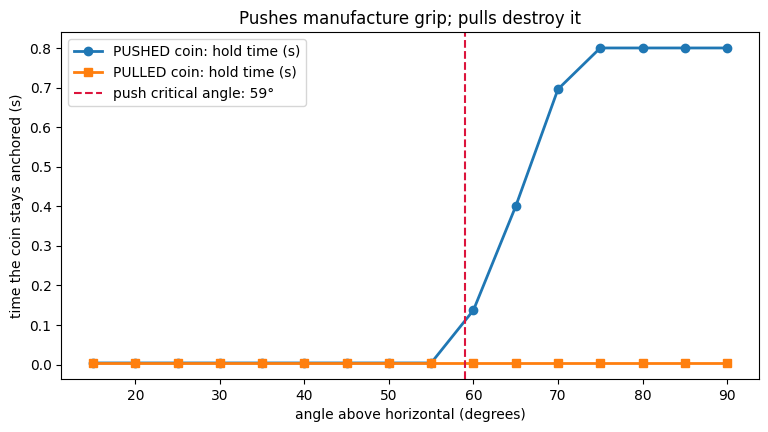

pulled coin's longest hold across ALL angles: 4 ms
pushed coin's holds range from instant skitter to the full window


In [2]:
def coin_hold_time(angle_degrees, power_class):
    """Seconds until the coin FIRST leaves its spot (pulled coins oscillate
    through Wax and can revisit their birthplace, so 'last seen at start'
    would lie — we measure first departure)."""
    radians = np.radians(angle_degrees)
    world = World()
    coin = world.add_body(Body("coin", 0.004, (0, 0.01), radius_m=0.01, is_metal=True))
    wax = world.add_body(Body("wax", 80, (-2.5 * np.cos(radians), 0.01 + 2.5 * np.sin(radians))))
    power = world.add_power(power_class(wax, coin, 2000))
    power.active = True
    window_seconds = 0.8
    for _ in range(int(window_seconds / world.dt_seconds)):
        world.step()
        if np.linalg.norm(coin.position - [0, 0.01]) > 1e-4:
            return world.time_seconds
    return window_seconds  # never moved

angles = np.arange(15, 91, 5)
push_holds = [coin_hold_time(a, Steelpush) for a in angles]
pull_holds = [coin_hold_time(a, Ironpull) for a in angles]

figure, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(angles, push_holds, "o-", linewidth=2, label="PUSHED coin: hold time (s)")
ax.plot(angles, pull_holds, "s-", linewidth=2, label="PULLED coin: hold time (s)")
ax.axvline(np.degrees(np.arctan(1 / 0.6)), color="crimson", linestyle="--",
           label="push critical angle: 59°")
ax.set_xlabel("angle above horizontal (degrees)")
ax.set_ylabel("time the coin stays anchored (s)")
ax.set_title("Pushes manufacture grip; pulls destroy it")
ax.legend()
plt.show()

print(f"pulled coin's longest hold across ALL angles: {max(pull_holds)*1000:.0f} ms")
print(f"pushed coin's holds range from instant skitter to the full window")

## Experiment B — the grapple

The Lurcher's real transport: a fixed beam 8 m up and 10 m out (a building's
metal bones). Flaring 5000 N — he has to break his own boot-grip before
anything else happens — he arcs up toward it and releases at 1.5 m to avoid
eating the lamppost. The beam, being the planet's, does not care.

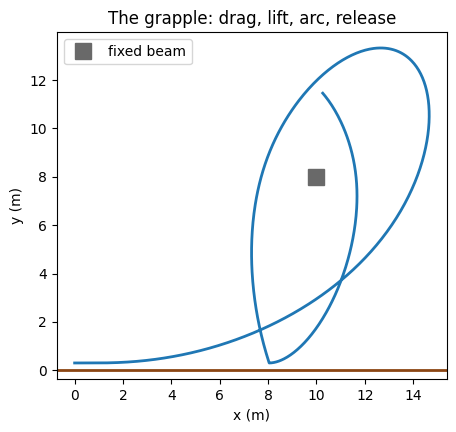

peak height 13.3 m, peak speed 23.2 m/s
note the start: he SLIDES first — the pull must overcome his boot-grip
(reduced by the pull's own lift!) before it can take him airborne


In [3]:
world = World()
beam = world.add_body(Body("beam", 50, (10, 8), radius_m=0.2, is_metal=True, is_fixed=True))
wax = world.add_body(Body("wax", 80, (0, 0.3)))
pull = world.add_power(Ironpull(wax, beam, 5000))
pull.active = True
release_point = None
for _ in range(int(4.0 / world.dt_seconds)):
    world.step()
    if pull.active and np.linalg.norm(beam.position - wax.position) < 1.5:
        pull.active = False
        release_point = wax.position.copy()

data = world.history.body("wax")
figure, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(data["x"], data["y"], linewidth=2)
ax.plot(*beam.position, "s", markersize=12, color="dimgray", label="fixed beam")
if release_point is not None:
    ax.plot(*release_point, "x", markersize=10, color="crimson", label="releases the pull")
ax.axhline(0, color="saddlebrown", linewidth=2)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("The grapple: drag, lift, arc, release")
ax.legend()
ax.set_aspect("equal")
plt.show()

peak_speed = np.sqrt(data["vx"]**2 + data["vy"]**2).max()
print(f"peak height {data['y'].max():.1f} m, peak speed {peak_speed:.1f} m/s")
print("note the start: he SLIDES first — the pull must overcome his boot-grip")
print("(reduced by the pull's own lift!) before it can take him airborne")

## Findings

1. **The asymmetry emerged as predicted**: pushed coins hold up to and past
   the 59° cliff; pulled coins come free in milliseconds at *every* angle.
   Nothing in `ironpull.py` knows about friction — the sign flip plus the
   normal-force physics produces the whole doctrine.
2. **The canon class hierarchy is now mechanical**: a Coinshot is
   self-sufficient (one pocket coin = an 18.9 m launch, notebook 02); a
   Lurcher's mobility is hostage to the world's fixed metal. Same force,
   opposite relationship to infrastructure.
3. **The Lurcher's combat niche is theft**: loose metal always comes free
   and always comes *toward you*. Pulling weapons out of hands is the
   attack the physics actively favors — filed to IDEAS.md for the fight
   sims and, of course, for the sports league's rules committee.
4. **The grapple works and tells a story in one trajectory**: slide (boot
   grip, weakened by the pull's own lift, finally overwhelmed), then sweep
   up the arc, then release and fly. Three regimes of the same 30-line
   force.
5. **Next: projectiles** — pushing off a moving bullet (the friend's
   near-teleport hypothesis vs the momentum ledger) and the two-point
   rigid bullet for emergent bubble-boundary deflection.